# 🛒 Walmart Weekly Sales Forecasting
### ISOM 678 — Final Project

**Dataset:** Walmart store sales (2010–2012) across 45 stores  
**Tasks:**
- **Inference:** Identify factors that significantly impact weekly sales  
- **Prediction:** Build ML models to forecast weekly sales (last 30 weeks = test set)  
- **Deep Learning:** Train and evaluate an MLP neural network  
---

## Libraries

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

## Data Loading

In [ ]:
stores   = pd.read_csv('https://zhang-datasets.s3.us-east-2.amazonaws.com/stores.csv')
sales    = pd.read_csv('https://zhang-datasets.s3.us-east-2.amazonaws.com/sales.csv')
features = pd.read_csv('https://zhang-datasets.s3.us-east-2.amazonaws.com/features.csv')

print(f'stores.csv   → {stores.shape[0]:,} rows, {stores.shape[1]} cols')
print(f'sales.csv    → {sales.shape[0]:,} rows, {sales.shape[1]} cols')
print(f'features.csv → {features.shape[0]:,} rows, {features.shape[1]} cols')

print('\n── STORES ──');  display(stores.head(3))
print('── SALES ──');    display(sales.head(3))
print('── FEATURES ──'); display(features.head(3))

stores.csv   → 45 rows, 3 cols
sales.csv    → 421,570 rows, 5 cols
features.csv → 8,190 rows, 12 cols

── STORES ──


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392


── SALES ──


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False


── FEATURES ──


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False



## Data Merging & Cleaning

In [ ]:
sales['Date']    = pd.to_datetime(sales['Date'])
features['Date'] = pd.to_datetime(features['Date'])

df = sales.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')

df = df.merge(stores, on='Store', how='left')

print(f'Merged dataframe: {df.shape[0]:,} rows × {df.shape[1]} columns')
display(df.head())

Merged dataframe: 421,570 rows × 16 columns


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [ ]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])

markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)

for col in ['CPI', 'Unemployment']:
    df[col].fillna(df[col].median(), inplace=True)

df = df[df['Weekly_Sales'] >= 0].reset_index(drop=True)

print(f'\nAfter cleaning → {df.shape[0]:,} rows')
print(f'Remaining missing values: {df.isnull().sum().sum()}')

Missing values per column:
MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138
dtype: int64

After cleaning → 420,285 rows
Remaining missing values: 0


## Exploratory Data Analysis (EDA)

In [ ]:
display(df.describe())

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,420285.000000,420285.000000,420285,420285.000000,420285.000000,420285.000000,420285.000000,420285.000000,420285.000000,420285.000000,420285.000000,420285.000000,420285.000000,420285.000000
mean,22.195477,44.242771,2011-06-18 07:22:30.395088640,16030.329773,60.090474,3.360888,2590.187246,878.803239,468.771234,1083.462694,1662.706138,171.212152,7.960077,136749.569176
min,1.000000,1.000000,2010-02-05 00:00:00,0.000000,-2.060000,2.472000,0.000000,-265.760000,-29.100000,0.000000,0.000000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2117.560000,46.680000,2.933000,0.000000,0.000000,0.000000,0.000000,0.000000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7659.090000,62.090000,3.452000,0.000000,0.000000,0.000000,0.000000,0.000000,182.350989,7.866000,140167.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20268.380000,74.280000,3.738000,2801.500000,2.400000,4.540000,425.290000,2168.040000,212.445487,8.567000,202505.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000
std,12.787213,30.507197,NaN,22728.500149,18.448260,0.458523,6053.225499,5076.525234,5533.593112,3895.801513,4205.946641,39.162280,1.863873,60992.688568


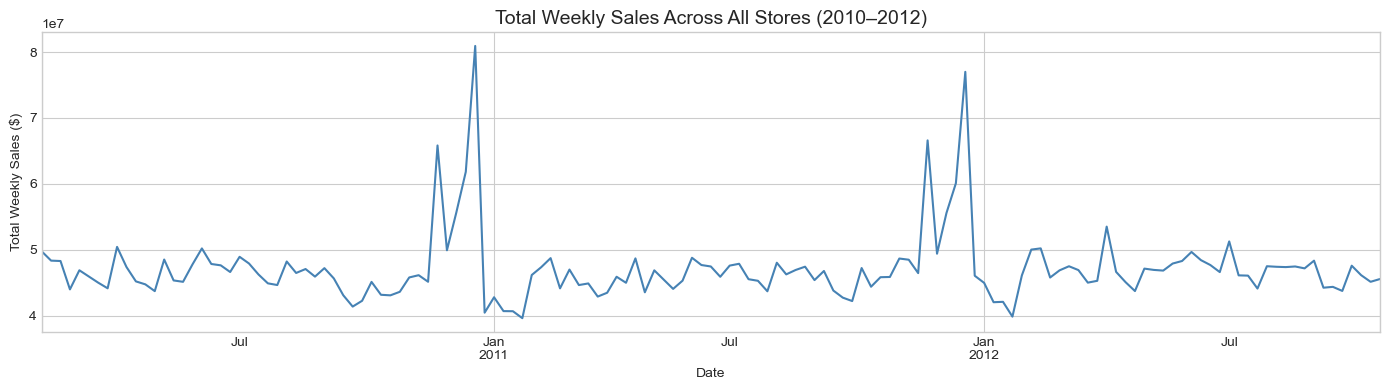

In [ ]:
# Total Weekly Sales Over Time 
weekly_total = df.groupby('Date')['Weekly_Sales'].sum()

plt.figure(figsize=(14, 4))
weekly_total.plot(color='steelblue')
plt.title('Total Weekly Sales Across All Stores (2010–2012)', fontsize=14)
plt.ylabel('Total Weekly Sales ($)')
plt.xlabel('Date')
plt.tight_layout()
plt.savefig('plot1_sales_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

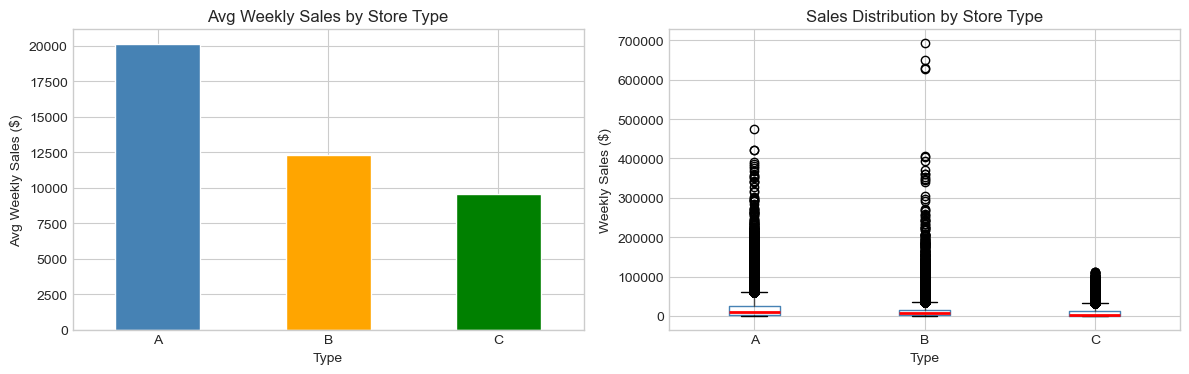

In [ ]:
# Average Sales by Store Type 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

type_sales = df.groupby('Type')['Weekly_Sales'].mean()
type_sales.plot(kind='bar', ax=axes[0],
                color=['steelblue', 'orange', 'green'], edgecolor='white')
axes[0].set_title('Avg Weekly Sales by Store Type')
axes[0].set_ylabel('Avg Weekly Sales ($)')
axes[0].set_xticklabels(['A', 'B', 'C'], rotation=0)

df.boxplot(column='Weekly_Sales', by='Type', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Sales Distribution by Store Type')
axes[1].set_ylabel('Weekly Sales ($)')
plt.suptitle('') 

plt.tight_layout()
plt.savefig('plot2_sales_by_type.png', dpi=150, bbox_inches='tight')
plt.show()

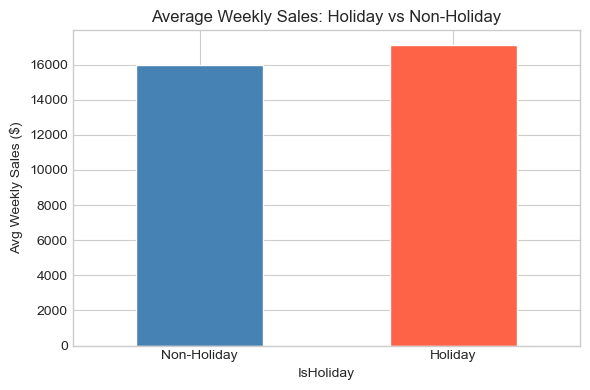

Holiday weeks generate 7.2% higher avg sales than non-holiday weeks.


In [ ]:
# Holiday vs Non-Holiday Average Sales 
holiday_means = df.groupby('IsHoliday')['Weekly_Sales'].mean()

plt.figure(figsize=(6, 4))
holiday_means.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Average Weekly Sales: Holiday vs Non-Holiday')
plt.xticks([0, 1], ['Non-Holiday', 'Holiday'], rotation=0)
plt.ylabel('Avg Weekly Sales ($)')
plt.tight_layout()
plt.savefig('plot3_holiday_effect.png', dpi=150, bbox_inches='tight')
plt.show()

# Quantify the difference as a percentage
pct_diff = (holiday_means[True] - holiday_means[False]) / holiday_means[False] * 100
print(f'Holiday weeks generate {pct_diff:.1f}% higher avg sales than non-holiday weeks.')

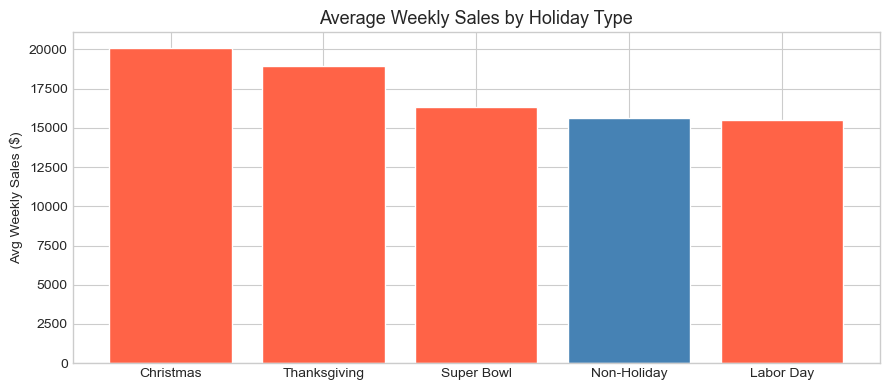

Average sales by holiday type:
Holiday_Type
Christmas       $20,089
Thanksgiving    $18,967
Super Bowl      $16,334
Non-Holiday     $15,651
Labor Day       $15,502
Name: Weekly_Sales, dtype: object


In [ ]:
# Holiday Breakdown — The 4 specific Walmart holidays
df['Month'] = df['Date'].dt.month
df['Week']  = df['Date'].dt.isocalendar().week.astype(int)

df['Holiday_Type'] = 'Non-Holiday'
df.loc[(df['Month'] == 2)  & (df['Week'].between(5, 7)),   'Holiday_Type'] = 'Super Bowl'
df.loc[(df['Month'] == 9)  & (df['Week'].between(35, 37)), 'Holiday_Type'] = 'Labor Day'
df.loc[(df['Month'] == 11) & (df['Week'].between(46, 48)), 'Holiday_Type'] = 'Thanksgiving'
df.loc[(df['Month'] == 12) & (df['Week'].between(49, 52)), 'Holiday_Type'] = 'Christmas'

holiday_breakdown = df.groupby('Holiday_Type')['Weekly_Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 4))
colors = ['tomato' if h != 'Non-Holiday' else 'steelblue' for h in holiday_breakdown.index]
plt.bar(holiday_breakdown.index, holiday_breakdown.values, color=colors, edgecolor='white')
plt.title('Average Weekly Sales by Holiday Type', fontsize=13)
plt.ylabel('Avg Weekly Sales ($)')
plt.tight_layout()
plt.savefig('plot4_holiday_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

print('Average sales by holiday type:')
print(holiday_breakdown.apply(lambda x: f'${x:,.0f}'))

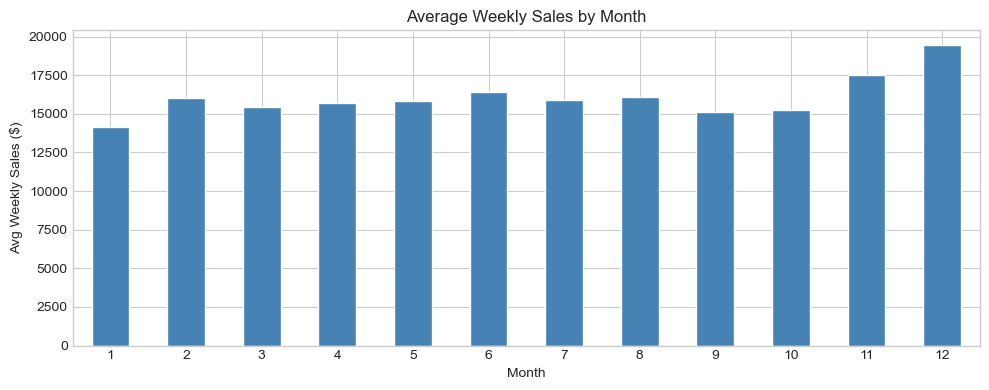

In [ ]:
# Average Weekly Sales by Month (seasonality)
monthly = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(10, 4))
monthly.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Average Weekly Sales by Month')
plt.xlabel('Month')
plt.ylabel('Avg Weekly Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot5_monthly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

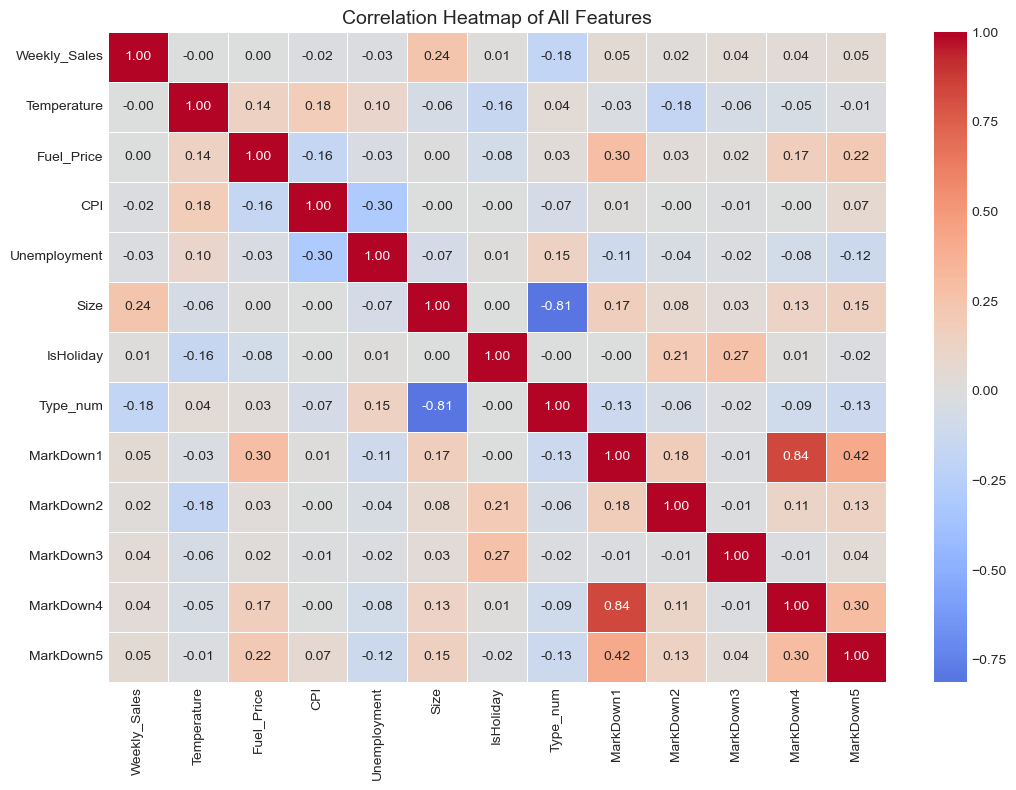

In [ ]:
# Correlation Heatmap 
df['Type_num'] = df['Type'].map({'A': 0, 'B': 1, 'C': 2})

numeric_cols = ['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI',
                'Unemployment', 'Size', 'IsHoliday', 'Type_num'] + markdown_cols

plt.figure(figsize=(11, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Heatmap of All Features', fontsize=14)
plt.tight_layout()
plt.savefig('plot6_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Engineering

In [ ]:
# Time-based features extracted from the Date column
df['Week']  = df['Date'].dt.isocalendar().week.astype(int)  
df['Month'] = df['Date'].dt.month                           
df['Year']  = df['Date'].dt.year                            

df['TotalMarkDown'] = df[markdown_cols].sum(axis=1)

df['Type'] = df['Type'].map({'A': 0, 'B': 1, 'C': 2})

FEATURES = [
    'Store', 'Dept',                               
    'IsHoliday',                                
    'Temperature', 'Fuel_Price', 'CPI',            
    'Unemployment',                                
    'Size', 'Type',                               
    'Week', 'Month', 'Year',                       
    'TotalMarkDown'                                
] + markdown_cols                                  

TARGET = 'Weekly_Sales'

print(f'Total features used in modeling: {len(FEATURES)}')
print('Features:', FEATURES)

Total features used in modeling: 18
Features: ['Store', 'Dept', 'IsHoliday', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size', 'Type', 'Week', 'Month', 'Year', 'TotalMarkDown', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']


## Train / Test Split

In [ ]:
df = df.sort_values('Date').reset_index(drop=True)

unique_dates = df['Date'].unique()
cutoff_date  = unique_dates[-30]  

print(f'Test set starts : {cutoff_date}')
print(f'Test set ends   : {unique_dates[-1]}')

train = df[df['Date'] < cutoff_date]
test  = df[df['Date'] >= cutoff_date]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f'\nTrain rows: {X_train.shape[0]:,} | Test rows: {X_test.shape[0]:,}')

Test set starts : 2012-04-06 00:00:00
Test set ends   : 2012-10-26 00:00:00

Train rows: 331,801 | Test rows: 88,484


## Inference — What Factors Drive Weekly Sales?

In [ ]:
# OLS
X_train_ols = X_train.copy().astype(float)
X_test_ols  = X_test.copy().astype(float)
X_train_ols = sm.add_constant(X_train_ols)
X_test_ols  = sm.add_constant(X_test_ols)
ols_model = sm.OLS(y_train.astype(float), X_train_ols).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:           Weekly_Sales   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.087
Method:                 Least Squares   F-statistic:                     1857.
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:11:35   Log-Likelihood:            -3.7866e+06
No. Observations:              331801   AIC:                         7.573e+06
Df Residuals:                  331783   BIC:                         7.573e+06
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          8.191e+05   2.61e+05      3.142

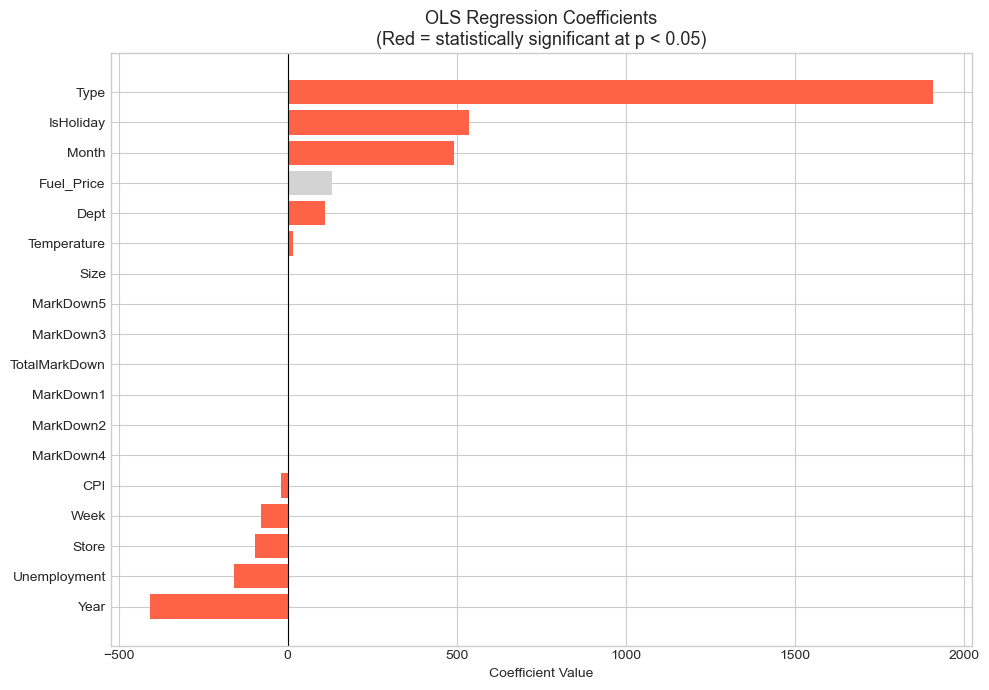


16 statistically significant features (p < 0.05):
                      coef         pvalue
Size              0.103151   0.000000e+00
Dept            111.485392   0.000000e+00
Store           -96.310840  1.746895e-204
Type           1908.989628   2.213976e-81
CPI             -18.889575   3.834432e-59
TotalMarkDown     0.039527   5.721133e-26
MarkDown3         0.060533   4.483452e-21
Unemployment   -158.752773   3.807616e-12
MarkDown2        -0.047740   7.416910e-12
Temperature      16.224153   1.080399e-11
MarkDown5         0.087919   1.538178e-10
MarkDown4        -0.086842   1.672376e-05
Month           492.658658   2.762499e-04
IsHoliday       536.926017   5.126267e-04
Year           -407.484499   1.700180e-03
Week            -77.619783   1.240011e-02


In [ ]:
# Visualize coefficients 
results_df = pd.DataFrame({
    'coef'  : ols_model.params,
    'pvalue': ols_model.pvalues
}).drop('const').sort_values('coef')
colors = ['tomato' if p < 0.05 else 'lightgrey' for p in results_df['pvalue']]

plt.figure(figsize=(10, 7))
plt.barh(results_df.index, results_df['coef'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('OLS Regression Coefficients\n(Red = statistically significant at p < 0.05)',
          fontsize=13)
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('plot7_ols_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

# Print only the significant features 
sig = results_df[results_df['pvalue'] < 0.05].sort_values('pvalue')
print(f'\n{len(sig)} statistically significant features (p < 0.05):')
print(sig[['coef', 'pvalue']].to_string())

## ML Models

In [ ]:
#Shared helper function
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Trains a model on X_tr/y_tr, predicts on X_te/y_te,
    and returns the model, predictions, RMSE, and R².
    """
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mse   = mean_squared_error(y_te, preds)
    rmse  = np.sqrt(mse)
    r2    = r2_score(y_te, preds)
    print(f'{name:25s} → RMSE: ${rmse:>10,.0f}  |  MSE: {mse:>15,.0f}  |  R²: {r2:.4f}')
    return model, preds, rmse, r2

results = {}

# Linear Regression (baseline) 
lr_model, lr_preds, lr_rmse, lr_r2 = evaluate_model(
    'Linear Regression',
    LinearRegression(),
    X_train, y_train, X_test, y_test
)
results['Linear Regression'] = {'RMSE': lr_rmse, 'R2': lr_r2}

# Random Forest
rf_model, rf_preds, rf_rmse, rf_r2 = evaluate_model(
    'Random Forest',
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test
)
results['Random Forest'] = {'RMSE': rf_rmse, 'R2': rf_r2}

# XGBoost 
xgb_model, xgb_preds, xgb_rmse, xgb_r2 = evaluate_model(
    'XGBoost',
    XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                 subsample=0.8, random_state=42, verbosity=0),
    X_train, y_train, X_test, y_test
)
results['XGBoost'] = {'RMSE': xgb_rmse, 'R2': xgb_r2}

Linear Regression         → RMSE: $    21,058  |  MSE:     443,424,618  |  R²: 0.0911
Random Forest             → RMSE: $     3,909  |  MSE:      15,283,300  |  R²: 0.9687
XGBoost                   → RMSE: $     6,053  |  MSE:      36,635,564  |  R²: 0.9249


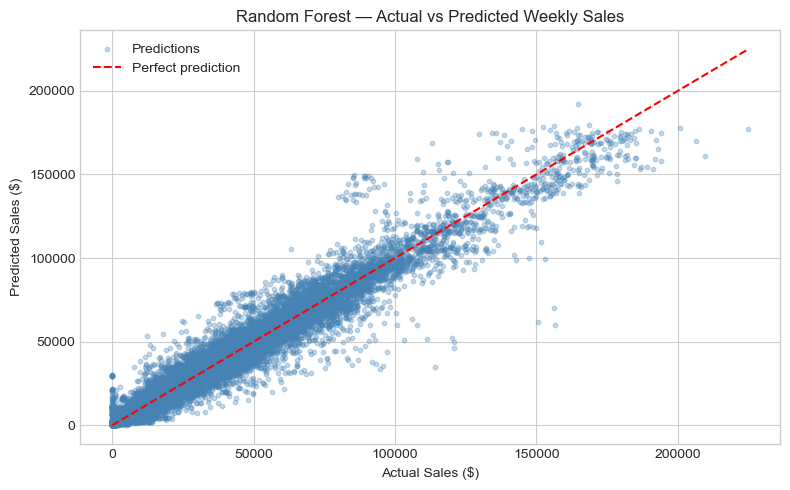

In [ ]:
# Actual vs Predicted — best traditional model (Random Forest) 
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_preds, alpha=0.3, s=10, color='steelblue', label='Predictions')
max_val = max(y_test.max(), rf_preds.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
plt.title('Random Forest — Actual vs Predicted Weekly Sales')
plt.xlabel('Actual Sales ($)')
plt.ylabel('Predicted Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('plot8_rf_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

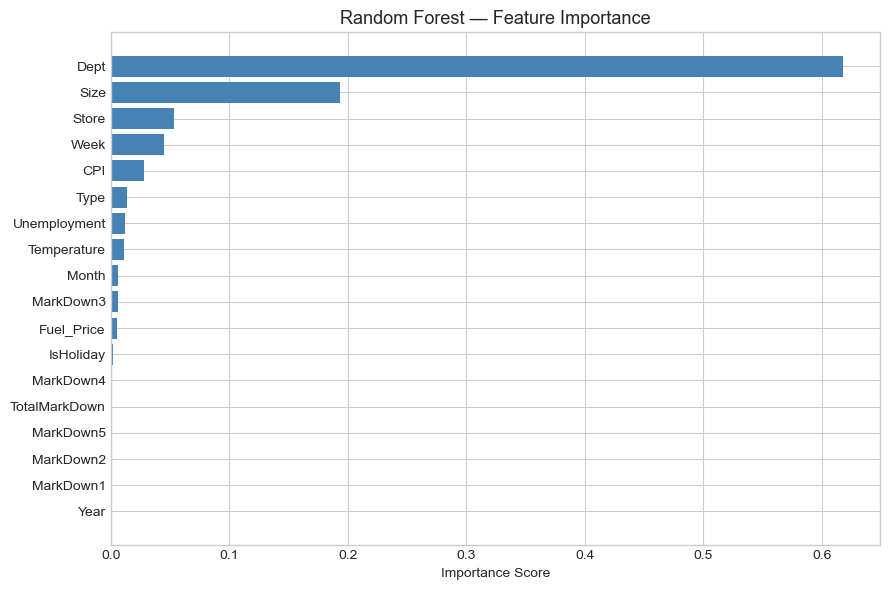

In [ ]:
# Random Forest Feature Importance 
importance_df = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.title('Random Forest — Feature Importance', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot9_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## MLP (Multi-Layer Perceptron)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled  = scaler.transform(X_test)       

# Convert numpy arrays to PyTorch tensors 
X_tr_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_tr_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)  
X_te_t = torch.tensor(X_test_scaled,  dtype=torch.float32)
y_te_t = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_tr_t, y_tr_t)
train_loader  = DataLoader(train_dataset, batch_size=512, shuffle=True)

print(f'Input features: {X_tr_t.shape[1]}')
print(f'Training batches per epoch: {len(train_loader)}')

Input features: 18
Training batches per epoch: 649


In [ ]:
# MLP architecture 
class SalesMLP(nn.Module):
    """
    Feedforward neural network for weekly sales regression.
    Architecture: Input → 256 → 128 → 64 → 1
    Regularization: BatchNorm + Dropout at each hidden layer
    """
    def __init__(self, input_dim):
        super(SalesMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),    
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),      
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


# Instantiate model
input_dim  = X_tr_t.shape[1]
mlp_model  = SalesMLP(input_dim)
criterion  = nn.MSELoss()                                             
optimizer  = torch.optim.Adam(mlp_model.parameters(),                 
                               lr=1e-3, weight_decay=1e-4)              
scheduler  = torch.optim.lr_scheduler.StepLR(optimizer,                
                                              step_size=20, gamma=0.5)

print(mlp_model)

SalesMLP(
  (net): Sequential(
    (0): Linear(in_features=18, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [ ]:
# Training loop
N_EPOCHS     = 60
train_losses = []  

mlp_model.train()  

for epoch in range(N_EPOCHS):
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()            
        preds = mlp_model(X_batch)       
        loss  = criterion(preds, y_batch) 
        loss.backward()                   
        optimizer.step()                 
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step()  

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:3d}/{N_EPOCHS}]  Avg MSE Loss: {avg_loss:,.0f}')

print('\n Training complete.')

Epoch [ 10/60]  Avg MSE Loss: 315,357,778
Epoch [ 20/60]  Avg MSE Loss: 284,747,100
Epoch [ 30/60]  Avg MSE Loss: 229,135,428
Epoch [ 40/60]  Avg MSE Loss: 218,311,044
Epoch [ 50/60]  Avg MSE Loss: 202,990,093
Epoch [ 60/60]  Avg MSE Loss: 199,160,036

 Training complete.


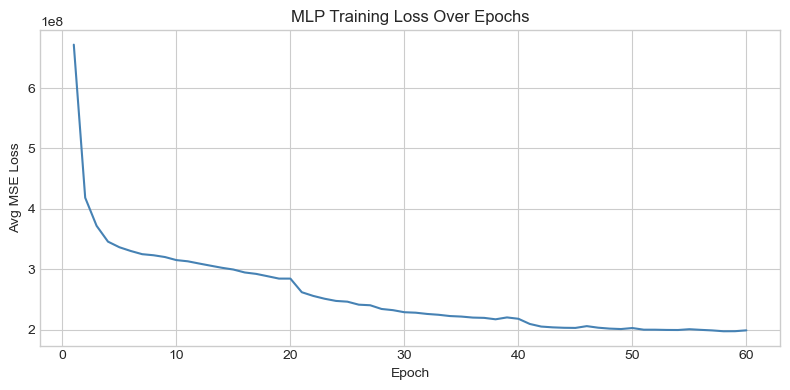

In [ ]:
#MLP Training Loss Curve 
plt.figure(figsize=(8, 4))
plt.plot(range(1, N_EPOCHS + 1), train_losses, color='steelblue')
plt.title('MLP Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Avg MSE Loss')
plt.tight_layout()
plt.savefig('plot10_mlp_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show() 

In [ ]:
#Evaluate MLP
mlp_model.eval()  

with torch.no_grad():  
    mlp_preds = mlp_model(X_te_t).squeeze().numpy()

mlp_mse  = mean_squared_error(y_test, mlp_preds)
mlp_rmse = np.sqrt(mlp_mse)
mlp_r2   = r2_score(y_test, mlp_preds)

print(f'MLP (Deep Learning) → RMSE: ${mlp_rmse:,.0f}  |  MSE: {mlp_mse:,.0f}  |  R²: {mlp_r2:.4f}')

results['MLP (Deep Learning)'] = {'RMSE': mlp_rmse, 'R2': mlp_r2}

MLP (Deep Learning) → RMSE: $13,549  |  MSE: 183,580,628  |  R²: 0.6237


---
## Section 9 — Final Model Comparison

 Final Model Comparison — Test Set Performance:


,Model,RMSE,R2
1,Random Forest,"$3,909",0.9687
2,XGBoost,"$6,053",0.9249
3,MLP (Deep Learning),"$13,549",0.6237
4,Linear Regression,"$21,058",0.0911


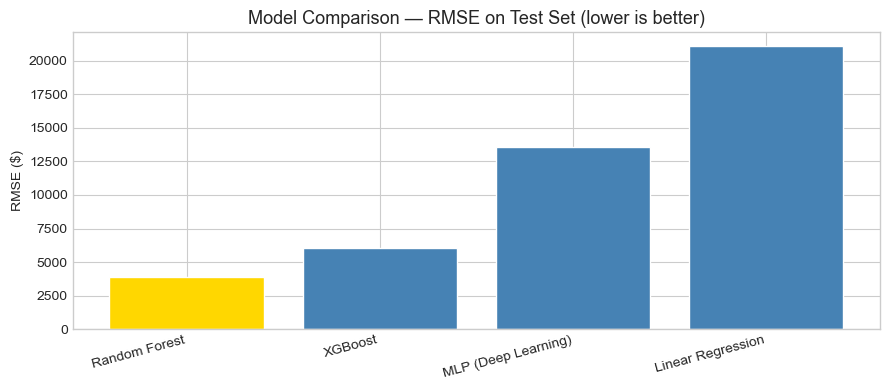


🏆 Best model: Random Forest — RMSE $3,909, R² 0.9687


In [ ]:
# Summary table of all models ranked by RMSE (lower = better)
final_df = pd.DataFrame(results).T.reset_index()
final_df.columns = ['Model', 'RMSE', 'R2']
final_df = final_df.sort_values('RMSE').reset_index(drop=True)
final_df.index += 1  

print(' Final Model Comparison — Test Set Performance:')
display(final_df.style
        .format({'RMSE': '${:,.0f}', 'R2': '{:.4f}'})
        .highlight_min(subset='RMSE', color='lightgreen'))

# Bar chart comparing RMSE across all models 
plt.figure(figsize=(9, 4))
bar_colors = ['gold' if i == 0 else 'steelblue' for i in range(len(final_df))]
plt.bar(final_df['Model'], final_df['RMSE'], color=bar_colors, edgecolor='white')
plt.title('Model Comparison — RMSE on Test Set (lower is better)', fontsize=13)
plt.ylabel('RMSE ($)')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('plot11_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best = final_df.iloc[0]
print(f'\n🏆 Best model: {best["Model"]} — RMSE ${best["RMSE"]:,.0f}, R² {best["R2"]:.4f}')

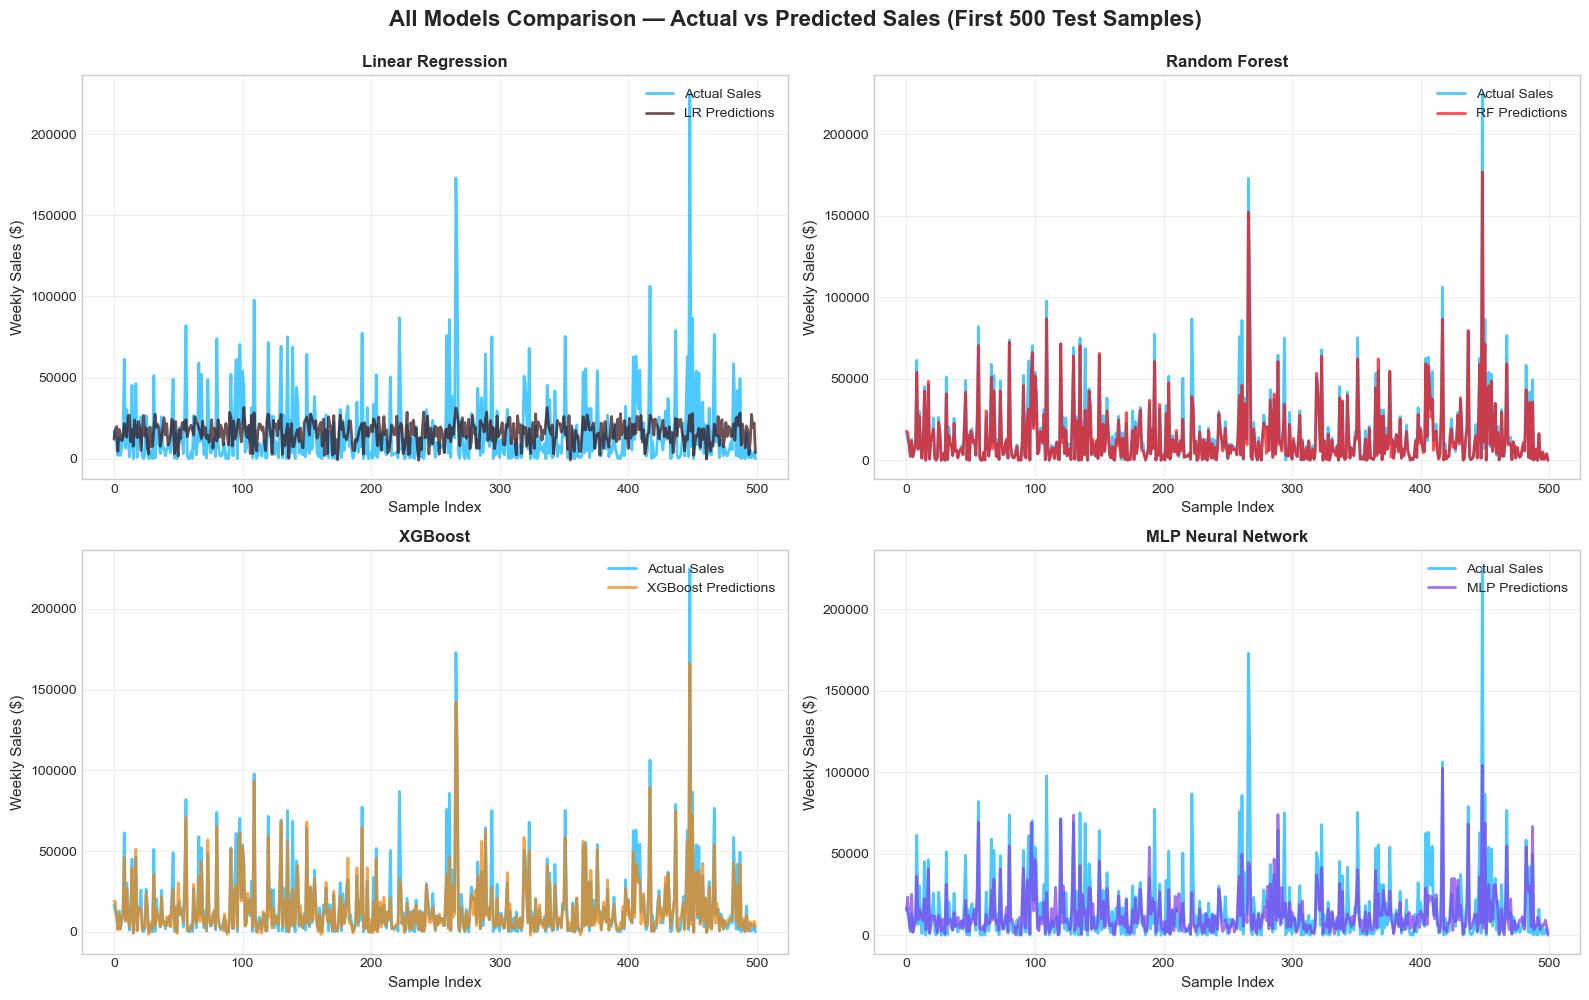

In [28]:
# ── Plot: Actual vs Predicted — ALL MODELS COMPARISON ────────────────────────

# Sample indices for clearer visualization (show first 500 samples)
sample_size = min(500, len(y_test))
sample_indices = np.arange(sample_size)

# Get actual values
y_true = y_test.values[:sample_size]

# Create subplots: 2 rows x 2 columns for all 4 models
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('All Models Comparison — Actual vs Predicted Sales (First 500 Test Samples)', 
             fontsize=16, fontweight='bold', y=0.995)

actual_color = "#00B3FF"
model_colors = {
    'Linear Regression': "#31090C",
    'Random Forest': "#FF0000",
    'XGBoost': '#F77F00',
    'MLP': '#8338EC'
}

# Calculate RMSE for each model on the sample
lr_rmse_sample = np.sqrt(mean_squared_error(y_true, lr_preds[:sample_size]))
rf_rmse_sample = np.sqrt(mean_squared_error(y_true, rf_preds[:sample_size]))
xgb_rmse_sample = np.sqrt(mean_squared_error(y_true, xgb_preds[:sample_size]))
mlp_rmse_sample = np.sqrt(mean_squared_error(y_true, mlp_preds[:sample_size]))

# Linear Regression 
axes[0, 0].plot(sample_indices, y_true, 
                label='Actual Sales', linewidth=2, alpha=0.7, color=actual_color)
axes[0, 0].plot(sample_indices, lr_preds[:sample_size], 
                label='LR Predictions', linewidth=2, alpha=0.7, color=model_colors['Linear Regression'])
axes[0, 0].set_xlabel('Sample Index', fontsize=11)
axes[0, 0].set_ylabel('Weekly Sales ($)', fontsize=11)
axes[0, 0].set_title(f'Linear Regression', 
                     fontsize=12, fontweight='bold')
axes[0, 0].legend(fontsize=10, loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# Random Forest 
axes[0, 1].plot(sample_indices, y_true, 
                label='Actual Sales', linewidth=2, alpha=0.7, color=actual_color)
axes[0, 1].plot(sample_indices, rf_preds[:sample_size], 
                label='RF Predictions', linewidth=2, alpha=0.7, color=model_colors['Random Forest'])
axes[0, 1].set_xlabel('Sample Index', fontsize=11)
axes[0, 1].set_ylabel('Weekly Sales ($)', fontsize=11)
axes[0, 1].set_title(f'Random Forest', 
                     fontsize=12, fontweight='bold')
axes[0, 1].legend(fontsize=10, loc='upper right')
axes[0, 1].grid(True, alpha=0.3)

# XGBoost 
axes[1, 0].plot(sample_indices, y_true, 
                label='Actual Sales', linewidth=2, alpha=0.7, color=actual_color)
axes[1, 0].plot(sample_indices, xgb_preds[:sample_size], 
                label='XGBoost Predictions', linewidth=2, alpha=0.7, color=model_colors['XGBoost'])
axes[1, 0].set_xlabel('Sample Index', fontsize=11)
axes[1, 0].set_ylabel('Weekly Sales ($)', fontsize=11)
axes[1, 0].set_title(f'XGBoost', 
                     fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=10, loc='upper right')
axes[1, 0].grid(True, alpha=0.3)

# MLP
axes[1, 1].plot(sample_indices, y_true, 
                label='Actual Sales', linewidth=2, alpha=0.7, color=actual_color)
axes[1, 1].plot(sample_indices, mlp_preds[:sample_size], 
                label='MLP Predictions', linewidth=2, alpha=0.7, color=model_colors['MLP'])
axes[1, 1].set_xlabel('Sample Index', fontsize=11)
axes[1, 1].set_ylabel('Weekly Sales ($)', fontsize=11)
axes[1, 1].set_title(f'MLP Neural Network', 
                     fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10, loc='upper right')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()